In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [27]:
data = pd.read_csv('Data/Position_Salaries.csv')
data.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [46]:
x = data.iloc[:,1:-1].values
y = data.iloc[:,-1].values
y = y.reshape(len(y),1)

In [49]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
x_scaled = sc_x.fit_transform(x)
y_scaled = sc_y.fit_transform(y)

In [50]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf')
svr.fit(x_scaled, y_scaled)

C:\Users\hicha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [54]:
predict = sc_y.inverse_transform(svr.predict(sc_y.transform([[6.5]])).reshape(-1, 1))
predict

array([[87714.85539438]])

Text(0, 0.5, 'Salary')

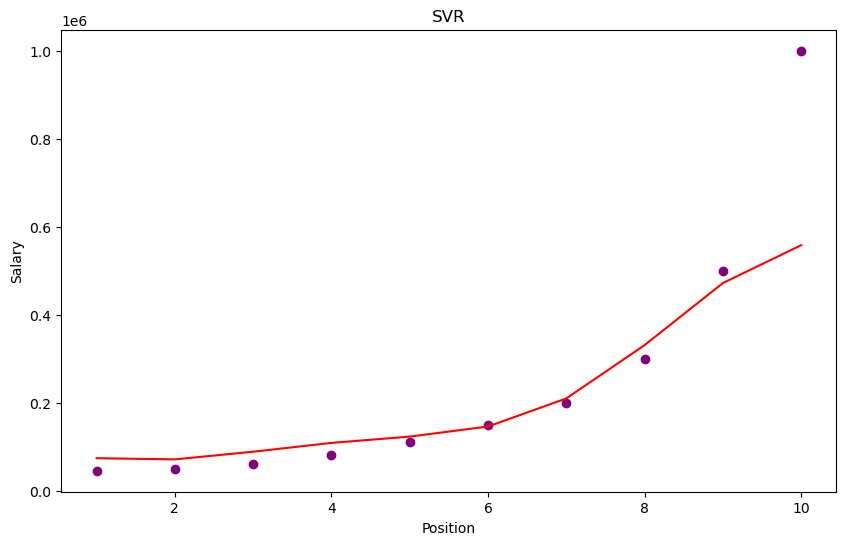

In [61]:
plt.figure(figsize=(10,6))
plt.scatter(x=sc_x.inverse_transform(x_scaled), y=sc_y.inverse_transform(y_scaled), color='purple')
plt.plot(sc_x.inverse_transform(x_scaled), sc_y.inverse_transform(svr.predict(x_scaled).reshape(-1, 1)), color='red')
plt.title('SVR')
plt.xlabel('Position')
plt.ylabel('Salary')